# Aula 2: primeiras redes no Keras

**Deep Learning (DEPAI) · IASEG**

Quatro exercícios, na ordem dos slides:

- **Exercício 1:** uma rede para regressão
- **Exercício 2:** contar os parâmetros
- **Exercício 3:** classificação binária (pontos no plano)
- **Exercício 4:** cédulas falsas

## Como usar este notebook

- Rodem as células **de cima para baixo**, uma por vez (`Shift + Enter`). Cada célula usa o que as anteriores criaram: se pularem uma, aparece um `NameError`.
- Onde aparecer `___`, completem o código antes de rodar a célula. Se rodarem com a lacuna, o Python avisa `NameError: name '___' is not defined`: é só o sinal de que falta completar.
- Se algo der errado no meio do caminho, `Ambiente de execução > Reiniciar e executar tudo` (no Colab) volta tudo ao início.

## A receita do Keras

Todo exercício segue os mesmos quatro passos. Os Exercícios 1 e 2 fazem só o primeiro; os Exercícios 3 e 4 fazem a receita completa.

| Passo | Comando | O que faz |
|---|---|---|
| 1. Montar | `keras.Sequential([...])` | Define as camadas e quantos neurônios cada uma tem |
| 2. Compilar | `modelo.compile(...)` | Escolhe como medir o erro (perda) e como ajustar os pesos (otimizador) |
| 3. Treinar | `modelo.fit(X, y, ...)` | Ajusta os pesos olhando os exemplos várias vezes |
| 4. Usar | `modelo.predict(X)` / `modelo.evaluate(X, y)` | Faz previsões / mede o desempenho |

## Configuração

O que cada biblioteca faz neste notebook:

- `numpy` (`np`): vetores e matrizes de números; é o formato que a rede recebe.
- `pandas` (`pd`): tabelas; usada para ler a base de cédulas no Exercício 4.
- `matplotlib.pyplot` (`plt`): gráficos.
- `keras`: monta, treina e usa as redes; `layers` reúne os tipos de camada (aqui só usamos `Dense`).

**Por que a semente?** Os pesos de uma rede começam com valores sorteados, e o treino também sorteia a ordem dos exemplos. Fixar a semente (`42`) faz todos sortearem os mesmos números, para os resultados de vocês ficarem iguais (ou bem próximos, se as máquinas forem diferentes).

In [1]:
# Só para quem for rodar fora do Colab (no Colab tudo já vem instalado).
# Tire o # da linha abaixo e execute esta célula uma vez.
%pip install numpy pandas matplotlib seaborn scikit-learn keras tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras import layers

keras.utils.set_random_seed(42)
print('Keras', keras.__version__)

Keras 3.15.1


---

# Exercício 1: uma rede para regressão

- Entrada: 2 números;
- Camada oculta: 10 neurônios, ReLU;
- Saída: 1 neurônio, **sem ativação** (o valor pode ser qualquer número, como numa regressão);
- Mostrar o resumo com `summary()`.

### Como ler o código da rede

- `keras.Sequential([...])`: uma lista de camadas. O dado entra na primeira e passa por todas, em ordem.
- `keras.Input(shape=(2,))`: não tem neurônios; só avisa o **formato de cada exemplo** (aqui, 2 números). A vírgula importa: `(2,)` é uma tupla com um elemento; `(2)` é só o número 2, e o Keras reclama.
- `layers.Dense(n, activation=...)`: camada **densa** com `n` neurônios. "Densa" porque cada neurônio recebe **todas** as saídas da camada anterior. Cada neurônio calcula

  $$\text{saída} = \text{ativação}(w_1 x_1 + w_2 x_2 + \dots + b)$$

  em que os $w$ são os pesos e $b$ é o bias.
- `activation="relu"`: ReLU devolve o próprio valor se for positivo e 0 se for negativo, $\max(0, z)$.
- **Sem `activation`**: o neurônio devolve a soma ponderada como está, qualquer número real. É o que queremos numa regressão: ReLU cortaria os negativos e a sigmoide prenderia tudo entre 0 e 1.

In [3]:
modelo = keras.Sequential([
    keras.Input(shape=(2,)),               # entrada: 2 valores
    layers.Dense(10, activation="relu"),   # oculta: 10 neurônios, ReLU
    layers.Dense(1),                       # saída: 1 valor, sem ativação
])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

### Como ler o `summary()`

- **Layer (type):** o nome e o tipo de cada camada. A entrada não aparece como linha: ela não tem parâmetros.
- **Output Shape:** o formato da saída da camada. Em `(None, 10)`, o `10` é um valor por neurônio; o `None` é o número de exemplos, que só fica definido quando os dados chegam.
- **Param #:** quantos números a camada aprende (pesos + bias).
- **Total / Trainable params:** a soma de tudo que o treino vai ajustar.

O total deve ser **41 parâmetros**. Pela fórmula, (entradas + 1) × neurônios:

- Camada oculta: (2 + 1) × 10 = 30;
- Saída: (10 + 1) × 1 = 11.

**De onde vem a fórmula?** Cada neurônio tem **um peso para cada entrada** que recebe, mais **um bias**. Repare que a camada de saída recebe 10 valores (as saídas dos 10 neurônios ocultos), e não os 2 da entrada da rede.

---

# Exercício 2: contar os parâmetros

- Entrada: 3 números;
- Camada oculta: 5 neurônios, ReLU;
- Saída: 1 neurônio, sem ativação.

**Antes de rodar:** quantos parâmetros tem cada camada? Usem a fórmula **(entradas + 1) × neurônios** e escrevam a conta na célula abaixo (pode ser a conta mesmo, como `(1 + 1) * 2`; o Python calcula).

**Dica:** para cada camada, perguntem "quantos valores chegam aqui?". Para a camada oculta, são os valores da entrada; para a camada de saída, são as saídas da camada oculta.

In [7]:
# Palpite (contas à mão)
param_oculta = (3 + 1) * 5
param_saida = (5 + 1) * 1

In [8]:
modelo = keras.Sequential([
    keras.Input(shape=(3,)),                 # entrada: 3 valores
    layers.Dense(5, activation="relu"),      # oculta: 5 neurônios
    layers.Dense(1),                         # saída: 1 valor, sem ativação
])
modelo.summary()
print('Palpite:', param_oculta, '+', param_saida, '=', param_oculta + param_saida)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Palpite: 20 + 6 = 26


O palpite bateu com o `summary()`? Se não bateu, comparem camada por camada com a coluna **Param #**.

A ativação (ReLU ou nenhuma) não muda a contagem: ela é uma função fixa, sem nada para aprender. Parâmetros são só pesos e bias.

---

# Exercício 3: classificação binária

Separar os pontos do **centro** (classe 1) dos pontos do **anel** (classe 0). Cada ponto tem 2 coordenadas, $(x, y)$.

**Por que este problema?** Não existe uma reta que separe o centro do anel: a fronteira certa é um círculo. É um bom teste para ver o que a camada oculta acrescenta.

A célula abaixo gera os dados (os mesmos dos slides) e desenha os pontos.

coordenadas: (240, 2) | rotulos: (240,)


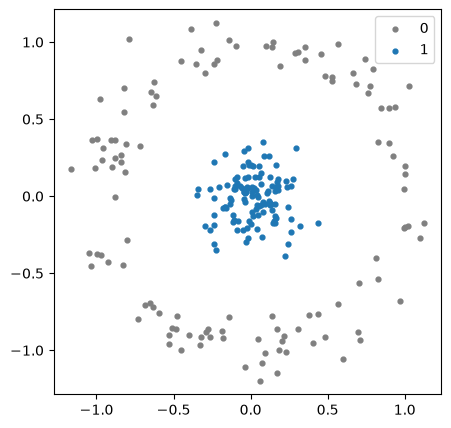

In [9]:
gerador = np.random.default_rng(42)
n = 120                                                      # pontos por classe

# Anel: ângulo qualquer, distância da origem perto de 1
angulo = gerador.uniform(0, 2 * np.pi, n)
raio = 1 + gerador.normal(0, 0.1, n)
anel = np.c_[raio * np.cos(angulo), raio * np.sin(angulo)]   # classe 0
# Centro: nuvem de pontos perto de (0, 0)
centro = gerador.normal(0, 0.15, (n, 2))                     # classe 1

coordenadas = np.r_[anel, centro]                # empilha: 240 linhas, 2 colunas
rotulos = np.r_[np.zeros(n), np.ones(n)]         # 120 zeros e depois 120 uns
print('coordenadas:', coordenadas.shape, '| rotulos:', rotulos.shape)

plt.figure(figsize=(5, 5))
plt.scatter(*anel.T, s=12, c='gray', label='0')
plt.scatter(*centro.T, s=12, c='tab:blue', label='1')
plt.legend(); plt.axis('equal'); plt.show()

Repare no formato: `coordenadas` tem **240 linhas** (um ponto por linha) e **2 colunas** (as coordenadas). É o `2` das colunas que vai no `shape` da entrada; o número de linhas não entra na rede. `rotulos` tem um 0 ou 1 para cada ponto, na mesma ordem.

## 3.1 Montar a rede

- Entrada: 2 coordenadas;
- Camada oculta: 8 neurônios, ReLU;
- Saída: 1 neurônio com **sigmoide** (a probabilidade da classe 1).

**Por que sigmoide e um neurônio só?** A sigmoide, $\sigma(z) = \frac{1}{1 + e^{-z}}$, transforma qualquer número em um valor entre 0 e 1, que lemos como a probabilidade da classe 1. Com duas classes, um número basta: a probabilidade da classe 0 é o que falta, $1 - p$.

In [10]:
keras.utils.set_random_seed(42)            # mesmos pesos iniciais para todos
modelo = keras.Sequential([
    keras.Input(shape=(3,)),                  # entrada
    layers.Dense(5, activation="relu"),        # oculta
    layers.Dense(1, activation="linear"),       # saída
])
modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

## 3.2 Compilar, treinar e prever

Duas classes: perda `"binary_crossentropy"`. Otimizador `"adam"`, 300 épocas.

O que cada peça faz:

- **`compile`** prepara o treino:
  - `loss` (perda): como medir o erro. A `binary_crossentropy` pune pouco quando a rede dá probabilidade alta para a classe certa e pune muito quando ela está confiante e errada.
  - `optimizer`: como ajustar os pesos para reduzir a perda. O `adam` é uma versão do gradiente descendente que ajusta o tamanho do passo sozinho; é um bom padrão.
  - `metrics=["accuracy"]`: só para acompanhar; não entra no ajuste dos pesos.
- **`fit`** treina. Uma **época** é uma passada por todos os exemplos; com 300 épocas, a rede vê cada ponto 300 vezes. `verbose=0` só esconde o registro de cada época.
- **`predict`** devolve uma probabilidade por ponto, num array de formato `(240, 1)`: uma linha por ponto, uma coluna por neurônio de saída.

Depois, o código transforma probabilidade em classe: `[:, 0]` pega a única coluna, `> 0.5` vira `True`/`False`, e `.astype(int)` vira 1/0. A média de `classes == rotulos` é a fração de acertos.

In [ ]:
modelo.compile(optimizer="___",
               loss="___",
               metrics=["accuracy"])
modelo.fit(coordenadas, rotulos, epochs=___, verbose=0)

previsoes = modelo.___(coordenadas)        # probabilidades entre 0 e 1
classes = (previsoes[:, 0] > 0.5).astype(int)
print('Acurácia no treino:', (classes == rotulos).mean())

Essa acurácia é medida **nos mesmos pontos usados no treino**, então tende a ser otimista. Aqui serve só para comparar redes; no Exercício 4 vamos medir num conjunto separado.

**Se a fronteira sair reta e a acurácia ficar bem abaixo de 1:** pode ser que alguns neurônios ReLU tenham "morrido". Se os pesos iniciais sorteados fazem a soma de um neurônio dar negativa para todos os pontos, a ReLU devolve sempre 0, e esse neurônio para de aprender. Com poucos neurônios, perder alguns faz falta: com 4 neurônios e esta semente, 2 morrem e a rede fica presa em 67%. Por isso usamos 8. Se acontecer com vocês, testem outra semente ou mais neurônios.

## 3.3 A fronteira de decisão

A função abaixo cria uma grade de 100 × 100 pontos cobrindo o plano, pergunta à rede a probabilidade da classe 1 em cada um e pinta o fundo com o resultado:

- **vermelho**: a rede diz classe 1 (probabilidade perto de 1);
- **azul**: a rede diz classe 0 (probabilidade perto de 0);
- a **fronteira de decisão** é onde a cor muda, isto é, onde a probabilidade passa por 0,5.

Aqui a previsão é feita sobre o plano todo, e os pontos de treino são desenhados por cima só para comparação.

In [ ]:
def desenhar_fronteira(modelo):
    eixo = np.linspace(-1.5, 1.5, 100)                   # 100 valores de -1,5 a 1,5
    gx, gy = np.meshgrid(eixo, eixo)                     # grade 100 x 100
    grade = np.c_[gx.ravel(), gy.ravel()]                # 10.000 pontos, 2 colunas
    p = modelo.predict(grade, verbose=0).reshape(gx.shape)
    plt.figure(figsize=(5, 5))
    plt.contourf(gx, gy, p, levels=20, cmap='RdBu_r', alpha=0.4, vmin=0, vmax=1)
    plt.scatter(*anel.T, s=12, c='gray', label='0')
    plt.scatter(*centro.T, s=12, c='tab:blue', label='1')
    plt.legend(); plt.axis('equal'); plt.show()

desenhar_fronteira(modelo)

**Para pensar:** e sem a camada oculta? Rodem a célula abaixo, que treina só `Dense(1, activation="sigmoid")`, uma regressão logística. O que acontece com a fronteira e com a acurácia?

In [ ]:
keras.utils.set_random_seed(42)            # mesmos pesos iniciais para todos
logistica = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(1, activation="sigmoid"),
])
logistica.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
logistica.fit(coordenadas, rotulos, epochs=300, verbose=0)

classes = (logistica.predict(coordenadas, verbose=0)[:, 0] > 0.5).astype(int)
print('Acurácia no treino:', (classes == rotulos).mean())
desenhar_fronteira(logistica)

**Depois de rodar:** um único neurônio com sigmoide calcula $\sigma(w_1 x + w_2 y + b)$, e a probabilidade passa por 0,5 exatamente onde $w_1 x + w_2 y + b = 0$, que é uma **reta**. Por isso a regressão logística não consegue cercar o centro: no máximo ela corta um pedaço do anel, e erra o resto.

Com a camada oculta, cada neurônio ReLU contribui com uma "dobra" em uma direção, e a saída combina essas dobras numa fronteira fechada em volta do centro. É isso que a camada oculta acrescenta.

---

# Exercício 4: cédulas falsas

## O problema

Uma máquina que confere cédulas (num banco, num caixa eletrônico, numa contadora de notas) fotografa cada nota e precisa decidir na hora: **verdadeira ou falsa?** Neste exercício, uma rede pequena faz esse papel.

## De onde vêm os dados

A base é a **Banknote Authentication**, do repositório de aprendizado de máquina da UCI (Universidade da Califórnia em Irvine), publicada em 2012 por pesquisadores da Hochschule Ostwestfalen-Lippe, na Alemanha.

- Foram fotografadas cédulas verdadeiras e cédulas falsas, com uma **câmera industrial** do tipo usado para inspecionar impressões.
- Cada foto tem 400 × 400 pixels, em tons de cinza, com resolução de cerca de 660 dpi (dá para ver detalhes bem finos da impressão).
- São **1.372 cédulas**: 762 verdadeiras e 610 falsas.

## Da foto para 4 números

A rede **não recebe a foto**. Antes, cada imagem passou por uma **transformada wavelet**, uma ferramenta que decompõe a imagem em detalhes de tamanhos diferentes: traços finos, texturas médias, regiões grandes. Dos valores que saem dessa decomposição, foram calculadas 4 estatísticas, que viraram as colunas da tabela:

| Coluna | Nome em português | Intuição |
|---|---|---|
| `variance` | variância | o quanto os detalhes variam: imagem com muito contraste fino ou imagem "lisa" |
| `skewness` | assimetria | se os valores pendem mais para um lado (mais claros ou mais escuros que a média) |
| `kurtosis` | curtose | se há muitos valores extremos, como picos de detalhe isolados |
| `entropy` | entropia | o quanto a imagem é "desordenada", difícil de prever de um ponto para o outro |

**Por que isso ajuda a achar falsificação?** Cédulas verdadeiras são impressas com técnicas e papel especiais, que deixam traços finos e nítidos. Uma impressora comum não reproduz bem esses detalhes, e a textura da imagem fica diferente. As 4 estatísticas são um resumo numérico dessa textura.

**Um detalhe curioso:** apesar dos nomes, a coluna `variance` tem valores negativos, e uma variância de verdade nunca é negativa. Os valores publicados passaram por alguma transformação que a documentação da base não detalha. Para o exercício, tratem as colunas como 4 medidas numéricas da textura; o que importa é se elas ajudam a separar as classes.

## O que é cada linha

Uma linha é uma cédula: as 4 colunas de medidas são as **entradas** da rede (`X`), e a coluna `class` é a **resposta certa** (`y`), com **1 para cédula falsa** e 0 para verdadeira.

## Por que é uma boa base para começar

- É pequena e treina em segundos.
- Todas as colunas são numéricas e não há valores faltando.
- As duas classes têm tamanhos parecidos (cerca de 56% e 44%).
- Diferente do Exercício 3, aqui **não sabemos de antemão** o formato da fronteira entre as classes. A exploração dos dados vai dar pistas.

A célula abaixo carrega a base direto da internet (é preciso estar conectado). `head()` mostra as 5 primeiras linhas.

In [ ]:
URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "00267/data_banknote_authentication.txt")
COLUNAS = ['variance', 'skewness', 'kurtosis', 'entropy']

cedulas = pd.read_csv(URL, header=None, names=COLUNAS + ['class'])
cedulas.head()

## 4.1 Explorar os dados

Antes de treinar, vale olhar os dados:

- `pairplot` com uma cor por classe (`hue`): cada gráfico fora da diagonal cruza duas variáveis; na diagonal, a distribuição de cada variável por classe. Se as cores aparecem bem separadas em algum gráfico, o problema tende a ser fácil.
- estatísticas de cada coluna (`describe`): reparem que as variáveis têm médias e desvios bem diferentes. Isso vai importar na padronização.
- quantas cédulas há em cada classe (`value_counts`): se uma classe for muito mais comum, acurácia alta pode não significar muito.

In [ ]:
import seaborn as sns

sns.pairplot(cedulas, hue="class")     # dispersão de cada par de variáveis
plt.show()

In [ ]:
print(cedulas.describe())                  # estatísticas de cada coluna
print(cedulas["class"].value_counts())     # cédulas por classe

## Divisão e padronização (pronto)

A mesma divisão para todos: 30% para teste, `random_state=42`, `stratify`. A padronização é aprendida **só no treino** e aplicada ao teste, como no curso de ML.

Por que cada passo:

- **Treino e teste:** a rede ajusta os pesos no treino; o teste fica guardado, com cédulas que ela nunca viu. A acurácia no teste é a estimativa honesta de como ela iria com cédulas novas.
- **`stratify=y`:** mantém a mesma proporção de falsas no treino e no teste.
- **`random_state=42`:** todos sorteiam a mesma divisão.
- **Padronização** (`StandardScaler`): transforma cada variável em $(x - \text{média}) / \text{desvio}$, para todas ficarem na mesma escala, em torno de 0. Variáveis em escalas muito diferentes atrapalham o gradiente descendente.
- **Só no treino:** a média e o desvio são calculados com o treino (`fit`) e aplicados aos dois (`transform`). Se usássemos o teste para calcular, informação do teste vazaria para o treino.

A última linha mostra uma **referência**: a acurácia de quem responde "verdadeira" para toda cédula. Como `class` vale 1 para falsa, `y_test.mean()` é a fração de falsas e `1 - y_test.mean()` é a de verdadeiras. Qualquer modelo útil precisa bater esse número.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = cedulas[COLUNAS].values      # as 4 variáveis (entradas)
y = cedulas['class'].values      # o rótulo: 1 = falsa, 0 = verdadeira

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

padronizador = StandardScaler().fit(X_train)   # média e desvio só do treino
X_train = padronizador.transform(X_train)
X_test = padronizador.transform(X_test)

print('Treino:', len(X_train), '| Teste:', len(X_test))
print('Referência (sempre "verdadeira"):', round(1 - y_test.mean(), 3))

## 4.2 Montar e compilar

- Entrada: as 4 variáveis;
- Sem camada oculta: 1 neurônio com sigmoide na saída (a probabilidade de a cédula ser falsa);
- Otimizador `"sgd"`, perda `"binary_crossentropy"`.

O `sgd` (*stochastic gradient descent*) é o gradiente descendente na forma mais simples, com passo fixo. A perda é a mesma do Exercício 3, porque de novo são duas classes.

**Antes de rodar:** quantos parâmetros essa rede tem?

In [ ]:
keras.utils.set_random_seed(42)            # mesmos pesos iniciais para todos
modelo = keras.Sequential([
    keras.Input(shape=(___,)),                  # 4 variáveis
    layers.Dense(___, activation="___"),        # probabilidade de ser falsa
])
modelo.compile(optimizer="___",
               loss="___",
               metrics=["accuracy"])
modelo.summary()

Sem camada oculta, um neurônio com sigmoide é uma **regressão logística**: (4 + 1) × 1 = 5 parâmetros.

## 4.3 Treinar e avaliar

20 épocas no treino; acurácia no teste com `evaluate`, que devolve `[perda, acurácia]`.

- O `fit` usa **só o treino** (`X_train`, `y_train`).
- O `evaluate` recebe as entradas **e** as respostas certas do teste, faz as previsões e já calcula a perda e as métricas do `compile`, nessa ordem. Por isso o `[1]` pega a acurácia. (Já o `predict` só recebe as entradas e devolve as probabilidades.)

In [ ]:
modelo.___(X_train, y_train, epochs=___, verbose=0)
acuracia = modelo.___(X_test, y_test, verbose=0)[1]
print('Acurácia no teste:', round(acuracia, 3))

**Para pensar:** a acurácia no teste bateu a referência? Por quanto? Uma regressão logística bastou, ou faria sentido pôr uma camada oculta?

Pista: lembrem do Exercício 3. A camada oculta ajudou porque a fronteira precisava ser curva. Os gráficos do `pairplot` sugerem que aqui as classes se separam bem com uma fronteira simples?

---

# Resumo da aula

**A receita:** montar (`Sequential`) → compilar (`compile`) → treinar (`fit`) → usar (`predict` / `evaluate`).

**Parâmetros de uma camada `Dense`:** (entradas + 1) × neurônios. As "entradas" de uma camada são as saídas da camada anterior.

**A última camada e a perda dependem da tarefa:**

| Tarefa | Última camada | Perda |
|---|---|---|
| Regressão (um número qualquer) | `Dense(1)`, sem ativação | `"mse"` (erro quadrático médio) |
| Classificação binária | `Dense(1, activation="sigmoid")` | `"binary_crossentropy"` |

**Erros comuns:**

- `shape=(2)` em vez de `shape=(2,)`;
- pular uma célula e receber `NameError`;
- medir a acurácia só no treino e achar que é a de dados novos;
- padronizar usando também o teste.